In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
## The base function you're going to use for curve fitting is a gaussian
## https://en.wikipedia.org/wiki/Gaussian_function

def gaussian(
    x, # domain of the function
    ctr, # mean of the function
    amp, # amplitude of the function
    mid, # midline of the function
    std # bandwidth parameter
):

    f = np.exp(-1*(((x-ctr)**2)/(2*std**2)))

    return mid+(amp*f)

In [3]:
## Now we're going to make sure it works by first making
## A set of data points to fit our gaussian to. Our 
## data points here come directly from a gaussian curve
## So curve_fit() should perfectly estimate the parameters

x = np.linspace(0,1,100) # we make a domain ranging from 0 to 1 with 100 linearly spaced points in between

y = gaussian(
    x, # pass the x
    0.5, # center of the gaussian
    1, # amplitude
    0, # midline
    0.2 # standard dev
)

Text(0.5, 1.0, 'Original gaussian')

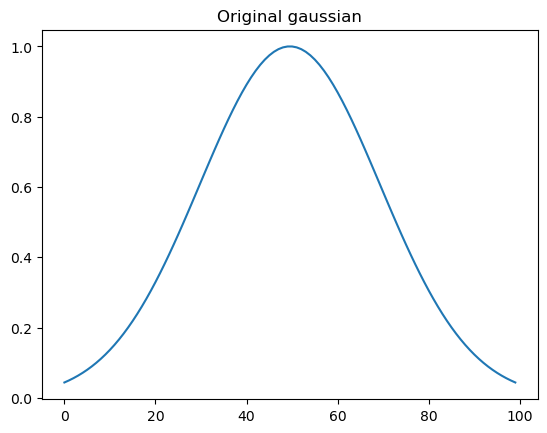

In [4]:
## Now we plot y just to see what it looks like, your curve fitting
## Should replicate this exactly
plt.plot(y)
plt.title("Original gaussian")

In [5]:
## The popt variable contains the parameters you need
## to pass to the gaussian function to best minimize the loss
popt, pcov = curve_fit(
    gaussian,
    x, y
)

In [6]:
## let's take a look and see if it did it right

print(popt) # the values are in scientific notation, but they all match very closely
            # note that since the midline is 0, the curve_fit() function returns something
            # really close to 0. 

[ 5.00000000e-01  1.00000000e+00 -3.93850251e-10  2.00000000e-01]


Text(0.5, 1.0, 'Estimate from curve fitting')

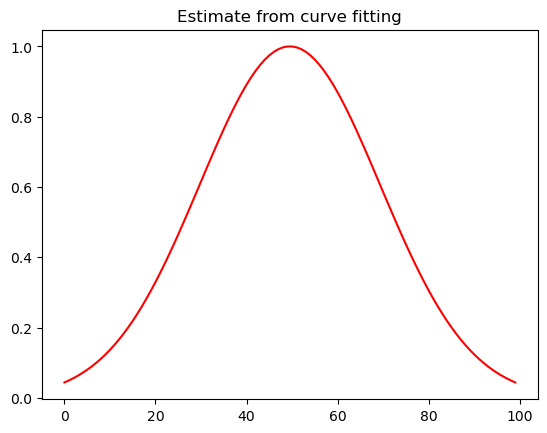

In [7]:
# Here we visualize that the curve fitting worked pretty much perfectly
# Although it may struggle a bit when there's a lot of noise in your data
# Note: the * operator unpacks the values in the list and uses each one as an argument.
plt.plot(gaussian(x, *popt), color = 'red')
plt.title("Estimate from curve fitting")

In [8]:
## Let's try adding some noise to the original gaussian and see how well the curve fitting does
y = y + np.random.normal(0,0.2,100)

Text(0.5, 1.0, 'Original gaussian with added noise')

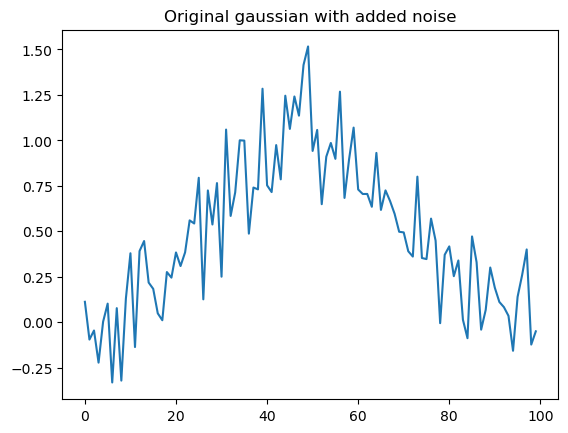

In [9]:
plt.plot(y)
plt.title("Original gaussian with added noise")

In [10]:
# redo the fitting
popt, pcov = curve_fit(
    gaussian,
    x, y
)

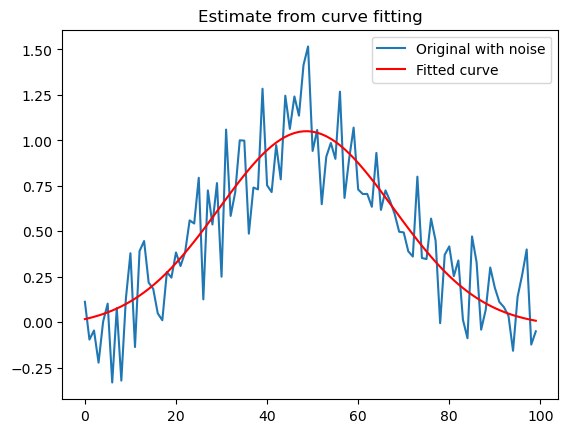

In [11]:
# and voila!

plt.plot(y, label = "Original with noise")
plt.plot(gaussian(x, *popt), color = 'red', label = "Fitted curve")
plt.title("Estimate from curve fitting")
plt.legend()

In [12]:
## For your purposes, you want to make sure that the midline is fixed at 0,
## So I made an objective function that only passes the user defined center, 
## amplitude, and standard dev to the gaussianfunction and always passes 0 for 
## the mideline parameter. You should use this instead of gaussian() when you
## fit your tuning curves; the popt variable should return the center, amplitude,
## and standard dev that best minimizes the loss
def objective_func(x, center, amplitude, standard_dev):
    return gaussian(x, center, amplitude, 0, standard_dev) 